# Pareto fronts under shuffled genetic codes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": ".9", "grid.linestyle": "--",
                             "axes.edgecolor": ".6", "xtick.bottom": True, "ytick.left": True})

import overlappingGenes as og
from overlappingGenes import (
    extract_params, load_natural_energies, make_shuffled_genetic_code, make_aa_permuted_genetic_code, set_genetic_code,
)
from replica_exchange import make_temperature_grid, replica_exchange, analyze_replicas

# Snapshot standard code before any modification
_STANDARD_TABLE   = dict(og.CODON_TABLE)
_STANDARD_NUMERIC = og.CODON_TABLE_NUMERIC.copy()

In [2]:
def within_and_distance(pareto_front, mu1, sig1, mu2, sig2):
    """Returns (within_pareto: bool, zscore_distance: float)."""
    within = False
    for pf_point in pareto_front:
        fz = np.array([(pf_point[0] - mu1) / sig1, (pf_point[1] - mu2) / sig2])
        if (fz[0] <= 0 and fz[1] <= 0 and (fz[0] < 0 or fz[1] < 0)):
            within = True
            break
    if not within:
        for pf_point in pareto_front:
            fz = np.array([(pf_point[0] - mu1) / sig1, (pf_point[1] - mu2) / sig2])
            if abs(fz[0]) < 1e-6 and abs(fz[1]) < 1e-6:
                within = True
                break
    pf_z = np.array([[(p[0] - mu1) / sig1, (p[1] - mu2) / sig2] for p in pareto_front])
    distances = np.sqrt(np.sum(pf_z**2, axis=1))
    zscore_dist = -float(np.min(distances)) if within else float(np.min(distances))
    return within, zscore_dist

def plot_pareto(run, pltlim = None):
    """Plot scatter of all samples + Pareto front + shaded dominated region + natural mean."""
    analysis = run["analysis"]
    samples = run["re_results"]["samples"]
    pf = analysis["pareto_front"]  # sorted by E1 ascending
    mu1, sig1 = run["mu1"], run["sig1"]
    mu2, sig2 = run["mu2"], run["sig2"]
    M = run["M"]

    fig, ax = plt.subplots(figsize=(4, 3))

    all_E1, all_E2 = [], []
    for a in range(M):
        for b in range(M):
            all_E1.extend(samples[(a, b)]["E1"].tolist())
            all_E2.extend(samples[(a, b)]["E2"].tolist())
    ax.scatter(all_E1, all_E2, s=1, alpha=0.1, color="gray", rasterized=True)

    # Shade the dominated region (upper-right of front)
    # Build polygon: front curve, then close via upper-right corner of plot
    pad = 0.05  # fraction of range for padding
    x_all = np.array(all_E1 + [mu1])
    y_all = np.array(all_E2 + [mu2])
    x_max = np.max(x_all) + pad * np.ptp(x_all)
    y_max = np.max(y_all) + pad * np.ptp(y_all)

    poly_x = np.concatenate([[pf[0, 0]], pf[:, 0], [x_max, x_max, pf[0, 0]]])
    poly_y = np.concatenate([[y_max], pf[:, 1], [pf[-1, 1], y_max, y_max]])
    ax.fill(poly_x, poly_y, color="gray", alpha=0.15, zorder=0, label="dominated region")

    ax.plot(pf[:, 0], pf[:, 1], "-", color="k", lw=.2, label="Pareto front")

    # Natural mean cross-hair (1 std dev arms)
    ax.plot([mu1 - sig1, mu1 + sig1], [mu2, mu2], "-", color="k", alpha=1)
    ax.plot([mu1, mu1], [mu2 - sig2, mu2 + sig2], "-", color="k", alpha=1)
    ax.plot(mu1, mu2, "o", color="k", ms=10, mew=2, label="natural mean")

    # Natural means as axes lines
    ax.axvline(mu1, color="k", alpha=1, ls="--")
    ax.axhline(mu2, color="k", alpha=1, ls="--")

    # ax.set_xlabel(f"$E_1$ ({run['pf1']})")
    # ax.set_ylabel(f"$E_2$ ({run['pf2']})")
    # ax.set_title(f"Pareto front  (overlap = {run['overlap_nuc']} nt)")

    if pltlim is not None:
        plt.xlim(pltlim[0], pltlim[1])
        plt.ylim(pltlim[2], pltlim[3])
    else:
        plt.ylim(bottom=min(y_all), top=max(y_all) + pad * np.ptp(y_all))
        plt.xlim(left=min(x_all), right=max(x_all) + pad * np.ptp(x_all))
        print(f"y-lim: {plt.ylim()}")
        print(f"x-lim: {plt.xlim()}")

    ax.grid(False)

    # ax.legend(fontsize=11)
    # plt.savefig(f"20260327 Replica Panels/20260327_Pareto_{run['pf1']}_{run['pf2']}_overlap{run['overlap_nuc']}nt.svg", dpi=300)
    plt.tight_layout()
    # plt.show()

## PF72 and PF9, overlap 211 (Frame -1)

In [3]:
# --- Parameters ---
PF1      = "PF00072"
PF2      = "PF00009"
OVERLAP  = 211 # 317 is longest -2, 211 is potentially interesting Frame -1
N_CODES  = 50
SEEDS    = list(range(N_CODES))

bmDCA_dir = "../0 bmDCA/"

# REMC settings
T1_vals, T2_vals = make_temperature_grid(T_min=0.1, T_max=1.0, M1=20, M2=20)
RE_KWARGS = dict(
    N_swap=1000, N_total=1_000_000,
    N_equil=100_000, N_thin=1000,
    discard_frac=0.2, quiet=False,
)

print(f"Frame for overlap of {OVERLAP} nt: -{OVERLAP % 3}")

Frame for overlap of 211 nt: -1


In [5]:
# --- Load DCA params + natural energies ---
J1, h1 = extract_params(f"{bmDCA_dir}{PF1}/{PF1}_params.dat")
J2, h2 = extract_params(f"{bmDCA_dir}{PF2}/{PF2}_params.dat")
DCA_1, DCA_2 = [J1, h1], [J2, h2]

L1 = len(h1) // 21
L2 = len(h2) // 21

ne1 = load_natural_energies(f"{bmDCA_dir}{PF1}/{PF1}_naturalenergies.txt")
ne2 = load_natural_energies(f"{bmDCA_dir}{PF2}/{PF2}_naturalenergies.txt")
mu1, sig1 = np.mean(ne1), np.std(ne1)
mu2, sig2 = np.mean(ne2), np.std(ne2)

max_overlap = min(L1, L2) * 3 - 6

print(f"{PF1}: L = {L1} AA,  <E> = {mu1:.1f} ± {sig1:.1f}")
print(f"{PF2}: L = {L2} AA,  <E> = {mu2:.1f} ± {sig2:.1f}")
print(f"Overlap: {OVERLAP} nt  (max = {max_overlap} nt)")
print(f"Temperature grid: {len(T1_vals)}×{len(T2_vals)} = {len(T1_vals)*len(T2_vals)} replicas")

PF00072: L = 108 AA,  <E> = 201.4 ± 30.0
PF00009: L = 162 AA,  <E> = 185.0 ± 36.4
Overlap: 211 nt  (max = 318 nt)
Temperature grid: 20×20 = 400 replicas


### Standard (wildtype) code

In [66]:
%%time
set_genetic_code(_STANDARD_TABLE, _STANDARD_NUMERIC)

re_std = replica_exchange(DCA_1, DCA_2, L1, L2, OVERLAP, T1_vals, T2_vals, **RE_KWARGS)
analysis_std = analyze_replicas(re_std, mu1, sig1, mu2, sig2)
within_std, z_std = within_and_distance(analysis_std["pareto_front"], mu1, sig1, mu2, sig2)

print(f"Standard code:  within={within_std},  z={z_std:+.3f}")

Initialised 36 replicas, each equilibrated for 100000 steps (20 workers)
  Round 500/5000
  Round 1000/5000
  Round 1500/5000
  Round 2000/5000
  Round 2500/5000
  Round 3000/5000
  Round 3500/5000
  Round 4000/5000
  Round 4500/5000
  Round 5000/5000
Standard code:  within=False,  z=+0.046
CPU times: user 20.1 s, sys: 2.92 s, total: 23 s
Wall time: 44.6 s


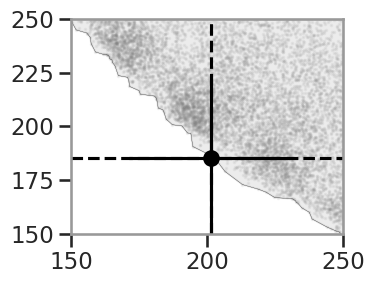

In [67]:
run = {}
run["analysis"] = analysis_std
run["re_results"] = re_std
run["mu1"], run["sig1"] = mu1, sig1
run["mu2"], run["sig2"] = mu2, sig2
run["M"] = len(T1_vals)
run["pf1"] = PF1
run["pf2"] = PF2


plot_pareto(run, pltlim=(150, 250, 150, 250))
# plt.savefig(f"20260327 Replica Panels/20260327_Pareto_{PF1}_{PF2}_overlap{OVERLAP}nt_standard.svg", dpi=300)

In [ ]:
# Shuffled code seed 25
set_genetic_code(_STANDARD_TABLE, _STANDARD_NUMERIC)
code_dict, code_numeric = make_shuffled_genetic_code(seed=25)
set_genetic_code(code_dict, code_numeric)

re = replica_exchange(DCA_1, DCA_2, L1, L2, OVERLAP, T1_vals, T2_vals, **RE_KWARGS)
analysis = analyze_replicas(re, mu1, sig1, mu2, sig2)
within, z = within_and_distance(analysis["pareto_front"], mu1, sig1, mu2, sig2)

run_shuffled = {}
run_shuffled["analysis"] = analysis
run_shuffled["re_results"] = re
run_shuffled["mu1"], run_shuffled["sig1"] = mu1, sig1
run_shuffled["mu2"], run_shuffled["sig2"] = mu2, sig2
run_shuffled["M"] = len(T1_vals)
run_shuffled["pf1"] = PF1
run_shuffled["pf2"] = PF2

print(f"Shuffled code:  within={within},  z={z:+.3f}")

Initialised 400 replicas, each equilibrated for 100000 steps (20 workers)
  Round 100/1000
  Round 200/1000
  Round 300/1000
  Round 400/1000
  Round 500/1000
  Round 600/1000
  Round 700/1000
  Round 800/1000
  Round 900/1000
  Round 1000/1000


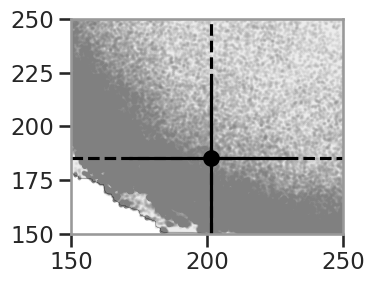

In [45]:
seed = 25
plot_pareto(run_shuffled, pltlim=(150, 250, 150, 250))
plt.savefig(f"20260327 Replica Panels/20260327_Pareto_{PF1}_{PF2}_overlap{OVERLAP}nt_shuffled_seed{seed}.svg", dpi=300)

In [ ]:
# Permuted code seed 25
seed = 0
set_genetic_code(_STANDARD_TABLE, _STANDARD_NUMERIC)
code_dict, code_numeric = make_aa_permuted_genetic_code(seed=seed)
set_genetic_code(code_dict, code_numeric)

re = replica_exchange(DCA_1, DCA_2, L1, L2, OVERLAP, T1_vals, T2_vals, **RE_KWARGS)
analysis = analyze_replicas(re, mu1, sig1, mu2, sig2)
within, z = within_and_distance(analysis["pareto_front"], mu1, sig1, mu2, sig2)

run_permuted = {}
run_permuted["analysis"] = analysis
run_permuted["re_results"] = re
run_permuted["mu1"], run_permuted["sig1"] = mu1, sig1
run_permuted["mu2"], run_permuted["sig2"] = mu2, sig2
run_permuted["M"] = len(T1_vals)
run_permuted["pf1"] = PF1
run_permuted["pf2"] = PF2

print(f"Permuted code:  within={within},  z={z:+.3f}")

Initialised 400 replicas, each equilibrated for 100000 steps (20 workers)
  Round 100/1000
  Round 200/1000
  Round 300/1000
  Round 400/1000
  Round 500/1000
  Round 600/1000
  Round 700/1000
  Round 800/1000
  Round 900/1000
  Round 1000/1000
Permuted code:  within=False,  z=+1.036


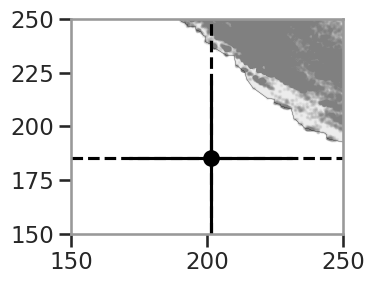

In [46]:
seed = 0
plot_pareto(run_permuted, pltlim=(150, 250, 150, 250))

plt.savefig(f"20260327 Replica Panels/20260327_Pareto_{PF1}_{PF2}_overlap{OVERLAP}nt_permuted_seed{seed}.svg", dpi=300)

## Overlap of 317, Frame -2

In [47]:
# --- Parameters ---
PF1      = "PF00072"
PF2      = "PF00009"
OVERLAP  = 317 # 317 is longest -2, 211 is potentially interesting Frame -1
N_CODES  = 50
SEEDS    = list(range(N_CODES))

bmDCA_dir = "../0 bmDCA/"

# REMC settings
T1_vals, T2_vals = make_temperature_grid(T_min=0.1, T_max=1.0, M1=20, M2=20)
RE_KWARGS = dict(
    N_swap=1000, N_total=1_000_000,
    N_equil=100_000, N_thin=1000,
    discard_frac=0.2, quiet=False,
)

print(f"Frame for overlap of {OVERLAP} nt: -{OVERLAP % 3}")

Frame for overlap of 317 nt: -2


In [48]:
# --- Load DCA params + natural energies ---
J1, h1 = extract_params(f"{bmDCA_dir}{PF1}/{PF1}_params.dat")
J2, h2 = extract_params(f"{bmDCA_dir}{PF2}/{PF2}_params.dat")
DCA_1, DCA_2 = [J1, h1], [J2, h2]

L1 = len(h1) // 21
L2 = len(h2) // 21

ne1 = load_natural_energies(f"{bmDCA_dir}{PF1}/{PF1}_naturalenergies.txt")
ne2 = load_natural_energies(f"{bmDCA_dir}{PF2}/{PF2}_naturalenergies.txt")
mu1, sig1 = np.mean(ne1), np.std(ne1)
mu2, sig2 = np.mean(ne2), np.std(ne2)

max_overlap = min(L1, L2) * 3 - 6

print(f"{PF1}: L = {L1} AA,  <E> = {mu1:.1f} ± {sig1:.1f}")
print(f"{PF2}: L = {L2} AA,  <E> = {mu2:.1f} ± {sig2:.1f}")
print(f"Overlap: {OVERLAP} nt  (max = {max_overlap} nt)")
print(f"Temperature grid: {len(T1_vals)}×{len(T2_vals)} = {len(T1_vals)*len(T2_vals)} replicas")

PF00072: L = 108 AA,  <E> = 201.4 ± 30.0
PF00009: L = 162 AA,  <E> = 185.0 ± 36.4
Overlap: 317 nt  (max = 318 nt)
Temperature grid: 20×20 = 400 replicas


## Standard (wildtype) code

In [49]:
%%time
set_genetic_code(_STANDARD_TABLE, _STANDARD_NUMERIC)

re_std = replica_exchange(DCA_1, DCA_2, L1, L2, OVERLAP, T1_vals, T2_vals, **RE_KWARGS)
analysis_std = analyze_replicas(re_std, mu1, sig1, mu2, sig2)
within_std, z_std = within_and_distance(analysis_std["pareto_front"], mu1, sig1, mu2, sig2)

print(f"Standard code:  within={within_std},  z={z_std:+.3f}")

Initialised 400 replicas, each equilibrated for 100000 steps (20 workers)
  Round 100/1000
  Round 200/1000
  Round 300/1000
  Round 400/1000
  Round 500/1000
  Round 600/1000
  Round 700/1000
  Round 800/1000
  Round 900/1000
  Round 1000/1000
Standard code:  within=True,  z=-0.856
CPU times: user 2min 6s, sys: 6.12 s, total: 2min 13s
Wall time: 2min 41s


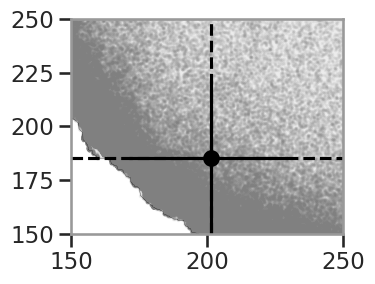

In [ ]:
run_2 = {}
run_2["analysis"] = analysis_std
run_2["re_results"] = re_std
run_2["mu1"], run_2["sig1"] = mu1, sig1
run_2["mu2"], run_2["sig2"] = mu2, sig2
run_2["M"] = len(T1_vals)
run_2["pf1"] = PF1
run_2["pf2"] = PF2


plot_pareto(run_2, pltlim=(150, 250, 150, 250))
# plt.savefig(f"20260327 Replica Panels/20260327_Pareto_{PF1}_{PF2}_overlap{OVERLAP}nt_standard.svg", dpi=300)

In [51]:
# Shuffled code seed 25
seed = 25
set_genetic_code(_STANDARD_TABLE, _STANDARD_NUMERIC)
code_dict, code_numeric = make_shuffled_genetic_code(seed=seed)
set_genetic_code(code_dict, code_numeric)

re = replica_exchange(DCA_1, DCA_2, L1, L2, OVERLAP, T1_vals, T2_vals, **RE_KWARGS)
analysis = analyze_replicas(re, mu1, sig1, mu2, sig2)
within, z = within_and_distance(analysis["pareto_front"], mu1, sig1, mu2, sig2)

run_shuffled_2 = {}
run_shuffled_2["analysis"] = analysis
run_shuffled_2["re_results"] = re
run_shuffled_2["mu1"], run_shuffled_2["sig1"] = mu1, sig1
run_shuffled_2["mu2"], run_shuffled_2["sig2"] = mu2, sig2
run_shuffled_2["M"] = len(T1_vals)
run_shuffled_2["pf1"] = PF1
run_shuffled_2["pf2"] = PF2

print(f"Shuffled code:  within={within},  z={z:+.3f}")

Initialised 400 replicas, each equilibrated for 100000 steps (20 workers)
  Round 100/1000
  Round 200/1000
  Round 300/1000
  Round 400/1000
  Round 500/1000
  Round 600/1000
  Round 700/1000
  Round 800/1000
  Round 900/1000
  Round 1000/1000
Shuffled code:  within=False,  z=+0.056


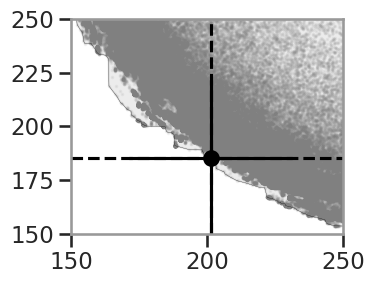

In [ ]:
plot_pareto(run_shuffled_2, pltlim=(150, 250, 150, 250))
# plt.savefig(f"20260327 Replica Panels/20260327_Pareto_{PF1}_{PF2}_overlap{OVERLAP}nt_shuffled_seed{seed}.svg", dpi=300)

In [53]:
# Permuted code seed 25
seed = 25
set_genetic_code(_STANDARD_TABLE, _STANDARD_NUMERIC)
code_dict, code_numeric = make_aa_permuted_genetic_code(seed=seed)
set_genetic_code(code_dict, code_numeric)

re = replica_exchange(DCA_1, DCA_2, L1, L2, OVERLAP, T1_vals, T2_vals, **RE_KWARGS)
analysis = analyze_replicas(re, mu1, sig1, mu2, sig2)
within, z = within_and_distance(analysis["pareto_front"], mu1, sig1, mu2, sig2)

run_permuted_2 = {}
run_permuted_2["analysis"] = analysis
run_permuted_2["re_results"] = re
run_permuted_2["mu1"], run_permuted_2["sig1"] = mu1, sig1
run_permuted_2["mu2"], run_permuted_2["sig2"] = mu2, sig2
run_permuted_2["M"] = len(T1_vals)
run_permuted_2["pf1"] = PF1
run_permuted_2["pf2"] = PF2

print(f"Permuted code:  within={within},  z={z:+.3f}")

Initialised 400 replicas, each equilibrated for 100000 steps (20 workers)
  Round 100/1000
  Round 200/1000
  Round 300/1000
  Round 400/1000
  Round 500/1000
  Round 600/1000
  Round 700/1000
  Round 800/1000
  Round 900/1000
  Round 1000/1000
Permuted code:  within=False,  z=+0.180


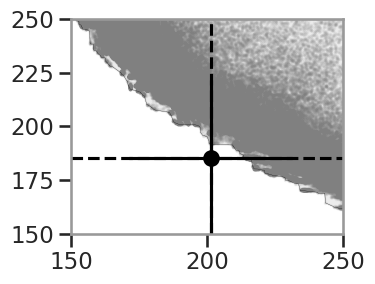

In [ ]:
plot_pareto(run_permuted_2, pltlim=(150, 250, 150, 250))

# plt.savefig(f"20260327 Replica Panels/20260327_Pareto_{PF1}_{PF2}_overlap{OVERLAP}nt_permuted_seed{seed}.svg", dpi=300)